In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_mobile_sales_2025.csv to synthetic_mobile_sales_2025.csv


In [3]:
import os
os.listdir()

['.config', 'synthetic_mobile_sales_2025.csv', 'sample_data']

In [4]:
df = pd.read_csv("synthetic_mobile_sales_2025.csv")
df.head()

,Sale_ID,Brand,Model,Country,Storage,Color,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Payment_Method,Sale_Month,Sale_Year
0,1,Realme,Realme Model 2,UK,512GB,Gold,656,20,13120,3.7,Installments,11,2025
1,2,Vivo,Vivo Model 20,Australia,512GB,Blue,1013,9,9117,3.7,Debit Card,2,2025
2,3,Motorola,Motorola Model 12,Germany,512GB,White,1471,7,10297,3.1,Credit Card,2,2025
3,4,Vivo,Vivo Model 13,USA,512GB,Gold,1220,19,23180,3.6,Debit Card,6,2025
4,5,Vivo,Vivo Model 15,UAE,128GB,Silver,375,8,3000,4.4,Online Payment,1,2025


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sale_ID          500 non-null    int64  
 1   Brand            500 non-null    object 
 2   Model            500 non-null    object 
 3   Country          500 non-null    object 
 4   Storage          500 non-null    object 
 5   Color            500 non-null    object 
 6   Price_USD        500 non-null    int64  
 7   Units_Sold       500 non-null    int64  
 8   Revenue_USD      500 non-null    int64  
 9   Customer_Rating  500 non-null    float64
 10  Payment_Method   500 non-null    object 
 11  Sale_Month       500 non-null    int64  
 12  Sale_Year        500 non-null    int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 50.9+ KB


,Sale_ID,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Sale_Month,Sale_Year
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.0
mean,250.500000,889.88400,10.458000,9279.282000,4.022600,6.588000,2025.0
std,144.481833,345.61789,5.710118,6474.699423,0.582329,3.414905,0.0
min,1.000000,302.00000,1.000000,302.000000,3.000000,1.000000,2025.0
25%,125.750000,572.00000,6.000000,3959.250000,3.575000,4.000000,2025.0
50%,250.500000,896.50000,10.000000,8086.500000,4.000000,7.000000,2025.0
75%,375.250000,1173.75000,15.000000,13331.250000,4.500000,10.000000,2025.0
max,500.000000,1500.00000,20.000000,29660.000000,5.000000,12.000000,2025.0


In [6]:
df['Rating_Category'] = df['Customer_Rating'].apply(
    lambda x: 1 if x >= 4 else 0
)

df[['Customer_Rating','Rating_Category']].head()

,Customer_Rating,Rating_Category
0,3.7,0
1,3.7,0
2,3.1,0
3,3.6,0
4,4.4,1


In [7]:
X = df[['Units_Sold','Revenue_USD']]
y = df['Rating_Category']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model Trained ✅")

Model Trained ✅


In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.49

Confusion Matrix:
 [[ 0 51]
 [ 0 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.49      1.00      0.66        49

    accuracy                           0.49       100
   macro avg       0.24      0.50      0.33       100
weighted avg       0.24      0.49      0.32       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


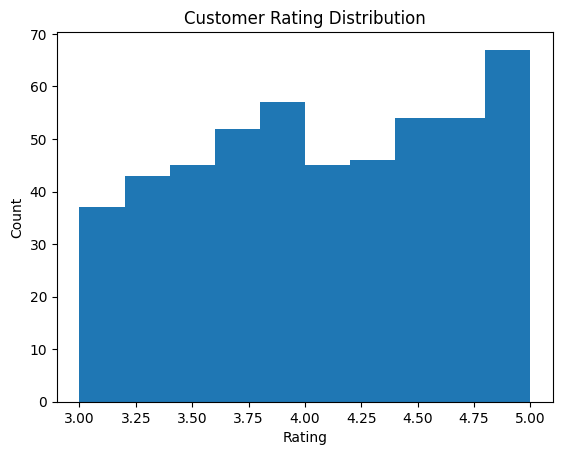

In [12]:
plt.hist(df['Customer_Rating'], bins=10)
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Model Insights

Logistic Regression predicts customer rating category.

Higher revenue and units sold influence ratings.

Model provides measurable prediction accuracy.

Dataset shows balanced rating distribution.